### Part A: Fit Gaussian distribution to the data

(a) Generate 5000 samples from a uniform distribution ${U}[0,5]$:

In [14]:
import torch

X = torch.rand(500)*5


(b) plot the histogram of the samples in (a)

In [ ]:
from matplotlib import pyplot as plt
import numpy as np

fig = plt.figure(figsize =(10, 7))

plt.hist(X, bins = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5,
                    4, 4.5, 5])

plt.title("Histogram of samples in **X**")

# show plot
plt.show()

(c) Fit a Gaussian distribution to the samples in (a).



In [ ]:
from scipy.stats import norm

mean,std=norm.fit(X)

plt.hist(X, bins=10, density=True)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
y = norm.pdf(x, mean, std)
plt.plot(x, y)
plt.show()


### Part B: Fit a GMM to the data ###

(d) Fit a GMM with different components to the data X in (a). Try with $K\in \{2,3,5\}$, where $K$ denotes the number of Gaussian components.

In [ ]:
from sklearn.mixture import GaussianMixture as GMM

K = 2

gmm = GMM(n_components=K, random_state=0).fit(X.numpy().reshape(-1,1))

x_new=gmm.sample(2000)[0]

fig, axs = plt.subplots(2)
fig.suptitle('Vertically stacked subplots')
axs[0].hist(X, bins=10, density=True, color='red')
axs[1].hist(x_new, bins=10, density=True, color='blue')



### Part C: Auto-encoders

(e) Train an autoencoder on MNIST dataset by using MSE

In [12]:
import torch
import torchvision as tv
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torchvision.utils import save_image

# Data Preprocessing

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
trainTransform  = tv.transforms.Compose([tv.transforms.ToTensor(), tv.transforms.Normalize((0.1307,), (0.3081,))])
trainset = tv.datasets.MNIST(root='./data',  train=True,download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(trainset, batch_size=32, shuffle=False, num_workers=4)
testset = tv.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False, num_workers=2)

# Defining Model

class Autoencoder(nn.Module):

    def __init__(self):
        super(Autoencoder,self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5),
            nn.ReLU(True),
            nn.Conv2d(6,16,kernel_size=5),
            nn.ReLU(True))

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16,6,kernel_size=5),
            nn.ReLU(True),
            nn.ConvTranspose2d(6,1,kernel_size=5),
            nn.ReLU(True),
            nn.Sigmoid())

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


# Defining Parameters

num_epochs = 5
batch_size = 128
model = Autoencoder().to('cuda')
distance = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),weight_decay=1e-5)


# Training
model.train()
for epoch in range(num_epochs):
    for data in dataloader:
        img, _ = data
        img = Variable(img).to('cuda')
        # ===================forward=====================
        output = model(img)
        loss = distance(output, img)
        # ===================backward====================
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # ===================log========================
    print('epoch [{}/{}], loss:{:.4f}'.format(epoch+1, num_epochs, loss.item()))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


epoch [1/5], loss:0.9751
epoch [2/5], loss:0.9749
epoch [3/5], loss:0.9749
epoch [4/5], loss:0.9748
epoch [5/5], loss:0.9748


(f) visualize a number of input and output samples from the test dataset

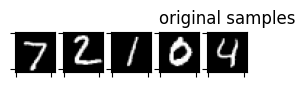

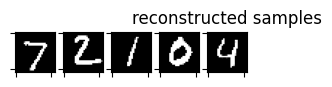

In [13]:
from matplotlib import pyplot as plt
import numpy as np

input, classes = next(iter(testloader))



z = model.encoder(input.to('cuda'))
output = model.decoder(z).cpu()

# ===========plot the original samples======================
fig, axs = plt.subplots(1, 5, figsize=(3, 3))
plt.title("original samples", loc='center')
idx = 0
for ax in axs:
    ax.imshow(input[idx,0,:,:].detach().numpy(),  cmap='gray')
    idx += 1
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])


plt.show()

# ===========plot the reconstructed samples======================

fig, axs = plt.subplots(1, 5, figsize=(3, 3))
plt.title("reconstructed samples", loc='center')
idx = 0
for ax in axs:
    ax.imshow(output[idx,0,:,:].detach().numpy(),  cmap='gray')
    idx += 1
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])


plt.show()


(g) Take random Gaussian noise as input to the decoder and check if the output images are similar to the input images or not.

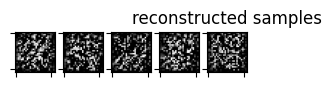

In [17]:
input, classes = next(iter(testloader))

z = model.encoder(input.to('cuda'))

# Take random Gaussian noise as input to the decoder
z = torch.randn_like(z)
output = model.decoder(z).cpu()



# ===========plot the reconstructed samples======================

fig, axs = plt.subplots(1, 5, figsize=(3, 3))
plt.title("reconstructed samples", loc='center')
idx = 0
for ax in axs:
    ax.imshow(output[idx,0,:,:].detach().numpy(),  cmap='gray')
    idx += 1
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])


plt.show()